# Modelos de difusión

In [1]:
import torch
import math
import torchvision
import matplotlib.pyplot as plt
from torch import nn
from torchvision import transforms
from torch.utils.data import DataLoader
import numpy as np
from tqdm import tqdm

/home/cienciasia/anaconda3/lib/python3.11/site-packages/torch/cuda/__init__.py:619: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


## Obtención de las imágenes y dataset

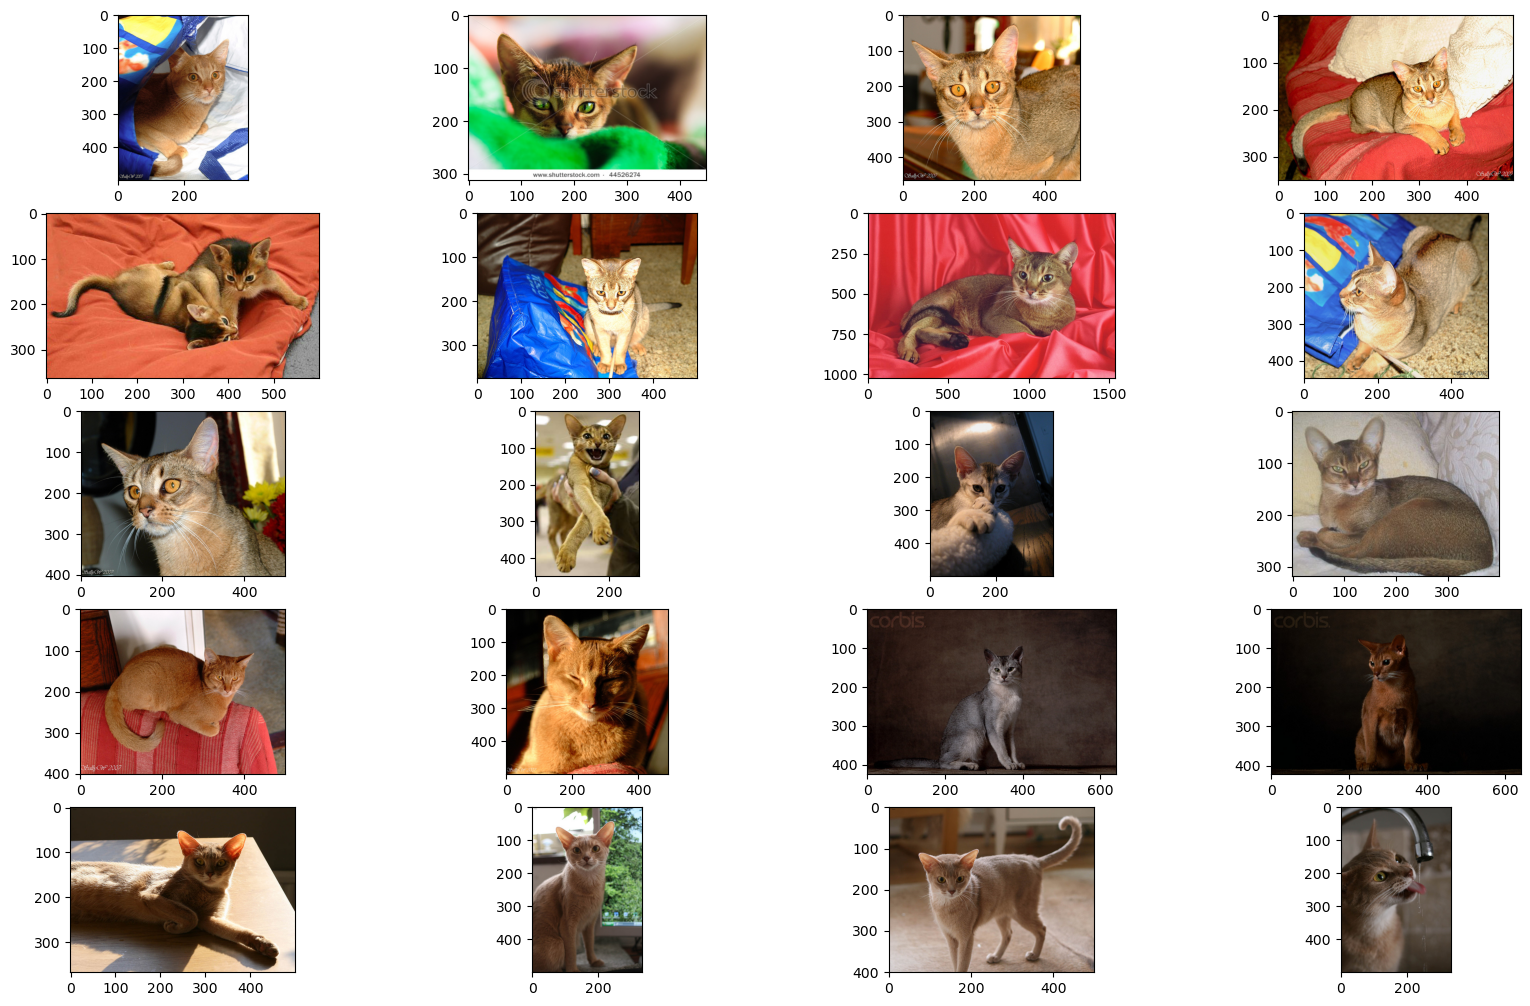

In [2]:
def show_images(datset, num_samples=20, cols=4):
    """ Función para visualizar imágenes del dataset """
    plt.figure(figsize=(20,15))
    for i, img in enumerate(datset):
        if i == num_samples:
            break
        plt.subplot(int(num_samples/cols + 1), cols, i + 1)
        plt.imshow(img[0])

#OxfordIIITPet dataset de imágenes de mascotas
data = torchvision.datasets.OxfordIIITPet(root=".", download=True)
show_images(data)

In [3]:
#Tamaño de imágenes
IMG_SIZE = 64
def load_transformed_dataset():
    """Carga el dataset con transformaciones, las transformaciones son comúnes a las imágenes que se aplican con
    torchvision.transform """
    data_transforms = [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(), # Scales data into [0,1]
        transforms.Lambda(lambda t: (t * 2) - 1) # Scale between [-1, 1]
    ]
    data_transform = transforms.Compose(data_transforms)
    train = torchvision.datasets.OxfordIIITPet(root=".", download=True, transform=data_transform)
    test = torchvision.datasets.OxfordIIITPet(root=".", download=True, transform=data_transform, split='test')

    return torch.utils.data.ConcatDataset([train, test])

def show_tensor_image(image):
    """Muestra las imágenes"""
    reverse_transforms = transforms.Compose([
        transforms.Lambda(lambda t: (t + 1) / 2),
        transforms.Lambda(lambda t: t.permute(1, 2, 0)), # CHW to HWC
        transforms.Lambda(lambda t: t * 255.),
        transforms.Lambda(lambda t: t.numpy().astype(np.uint8)),
        transforms.ToPILImage(),
    ])

    #Toma primera imagen del batch
    if len(image.shape) == 4:
        image = image[0, :, :, :]
    plt.imshow(reverse_transforms(image))

#Tamaño de Batches
BATCH_SIZE = 128

#Crarga las imagenes con DataLoader
data = load_transformed_dataset()
dataloader = DataLoader(data, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

Un modelo de difusión asume dos procesos de Márkov que determinan la introducción de ruido y su eliminación. El llamado procedimiento de avance introduce ruido al dato de entrada hasta que la estructura del dato se pierda. El procedimiento de retoroceso, por su parte, elimina el ruido para recuperar la imagen original, de tal forma que aplicada sobre una señal de ruido puede generar una imagen.

## Procedimiento de avance

El procedimiento de avance asume un a priori $x_0 \sim q(x_0)$ y un conjunto de probabilidades de transición que está determinado como:

$$q(x^{(1)}...x^{(T)}|x^{(0)}) = \prod_{t=1}$$

posterior_variance = betas * (1. - alphas_cumprod_prev) / (1. - alphas_cumprod)^T q(x^{(t)}|x^{(t-1)}) $$

donde $$q(x^{(t)}|x^{(t-1)}) = \mathcal{N}(x^{(t)};\sqrt{1-\beta_t}x^{(t-1)}, \beta_t I) $$


$$\alpha_t = 1 - \beta_t$$
$$\overline{\alpha}_t = \prod_{s=1}^t \alpha_s$$


La media y la varianza del modelo serán determinados como:

$$\hat{\mu}(x^{(t)}, x^{(0)}) = \frac{\sqrt{\overline{\alpha}_{t-1}} \beta_t}{1-\overline{\alpha_{t}}} x^{(0)} + \frac{\sqrt{\alpha_t}(1-\overline{\alpha}_{t-1})}{1-\alpha_{t}} x^{(t)}$$

$$\sigma^2 = \hat{\beta} = \frac{ 1-\overline{\alpha}_{t-1} }{ 1-\overline{\alpha}_t } \beta_t$$

In [4]:
#Definir el esquema de las betas
T = 100
betas = torch.linspace(0.0001, 0.02, T)

#a = 1-b
alphas = 1. - betas
#Producto de alphas a1*a2*...*at
alphas_cumprod = torch.cumprod(alphas, axis=0)
#Padding de las alphas previas
alphas_cumprod_prev = nn.functional.pad(alphas_cumprod[:-1], (1, 0), value=1.0)
#Recíproco de las alphas
sqrt_recip_alphas = torch.sqrt(1.0 / alphas)
#Cuadrado del producto de alphas
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
#Cuadrado de 1-alpha
sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)

#Varianza
posterior_variance = betas * (1. - alphas_cumprod_prev) / (1. - alphas_cumprod)

El modelo de difusión genera un proceso de transición gaussiano tal que:

$$q(x^{(t)}) = \mathcal{N}(x^{(t)}; \sqrt{\overline{\alpha}} x^{(0)}, (1-\overline{\alpha})I)$$

Así, dado $x^{(0)}$ , se obtendrá el muestreo de $x^{(t)}$ al tomar una muestra de un vector guassiano $\epsilon \sim \mathcal{N}(0,I)$ y se aplica la transformación:

$$x^{(t)} = \sqrt{\overline{\alpha}_t} x^{(0)} + \sqrt{1-\overline{\alpha}_t}\epsilon$$

donde $x^{(T)} \approx 0$ tiene a ser gaussiana en su distribución tal que:

$$q(x^{(T)}) = \int q(x^{(T)}|x^{(0)}) q(x^{(0)}) dx^{(0)}$$

In [5]:
def get_index_from_list(vals, t, x_shape):
    """Regresa un índice específico t de una lista de valores, considerando la dimensión del batch."""
    #Tamaño deñ batch (núm. de renglones)
    batch_size = t.shape[0]
    #Toma valores de un eje
    out = vals.gather(-1, t.cpu())

    return out.reshape(batch_size, *((1,) * (len(x_shape) - 1))).to(t.device)

def forward_diffusion_sample(x_0, t, device="cpu"):
    """Paso forward en el modelo de difusión (inserta ruido)"""
    #Genera ruido aleatoriamente
    noise = torch.randn_like(x_0)
    #Acumula la probabilidad de las alphas hasta t
    sqrt_alphas_cumprod_t = get_index_from_list(sqrt_alphas_cumprod, t, x_0.shape)
    #1 - probabilidad acumulada de alphas hasta t
    sqrt_one_minus_alphas_cumprod_t = get_index_from_list(sqrt_one_minus_alphas_cumprod, t, x_0.shape)

    #Media y varianza
    return sqrt_alphas_cumprod_t.to(device)*x_0.to(device) + sqrt_one_minus_alphas_cumprod_t.to(device)*noise.to(device), noise.to(device)

El paso de avance, por tanto, insertará ruido a una imagen hasta que la estrucutra de éste dato se difumine por el ruido.

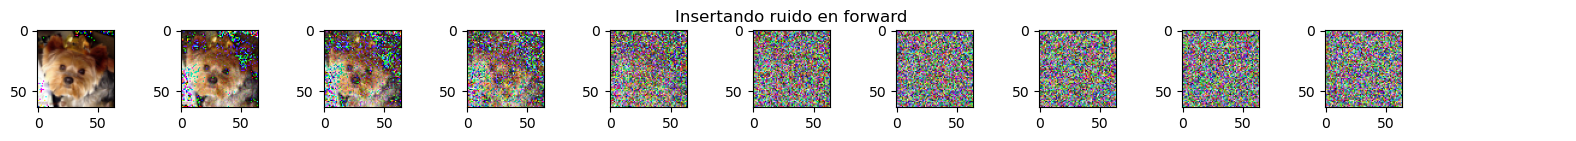

In [6]:
#Imagen para visualizar
image = next(iter(dataloader))[0]

def plot_forward(image):
    plt.figure(figsize=(20,1))
    plt.title('Insertando ruido en forward')
    plt.axis('off')
    num_images = 10
    stepsize = int(T/num_images)
    
    for idx in range(0, T, stepsize):
        t = torch.Tensor([idx]).type(torch.int64)
        plt.subplot(1, num_images+1, int(idx/stepsize) + 1)
        image, noise = forward_diffusion_sample(image, t)
        show_tensor_image(image)

plot_forward(image)

## Procedimiento de retroceso

El modelo de difusión utiliza un procedimiento de retroceso donde determina una cadena de Márkov inversa. Para esto, se agrega una codificación posicional sinusoidal determinada por pesos:

$$w_k = exp\big( -k \frac{\ln \omega}{H-1} \big)$$

donde $\omega$ es el warmup, generalmente con un valor de 10 000 y $H = d/2$ donde $d$ es la dimensión del modelo. Finalmente, se aplican funciones seno y coseno para generar el vector de posisión como:

$$pe_t = \begin{pmatrix} \sin(t\omega_0) \cdots \sin(t\omega_{H-1} & \cos(t\omega_0) \cdots \cos(t\omega_{H-1}) \end{pmatrix}$$

In [7]:
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim, warm=10000):
        super().__init__()
        self.dim = dim
        self.warm = warm

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(self.warm) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        
        return embeddings

En el retroceso, se tiene un a priori $p(x^{(T)}) = \mathcal{N}(x^{(T)}; 0, I)$ y se genera un kernel gaussiano que se debe aprender determinado por las probabilidades de transición:
$$p_\theta(x^{(t-1)} | x^{(t)})$$
el cual toma la forma:
$$p_\theta(x^{(t-1)} | x^{(t)}) = \mathcal{N}(x^{(t-1)}; \mu_\theta(x^{(t)},t), \Sigma_\theta(x^{(t)},t) )$$
Esta probabilidad se puede estimar de diferentes formas por medio de diferentes arquitecturas neuronales, particularmente a partir de una U-Net. Esta U-Net, que busca procesar la cadena de Márkov de avance y de retroceso en sus pasos. Para esto, se define el bloque de la U-Net simplemente aplicando capas convolucionales en el avance y capas de convoluciones transpuestas para la deconvolución en el retroceso. Definimos conexiones residuales entre ambos pasos.

Para insertar la variable del tiempo, se genera un simple embedding temporal que representa el paso temporal a partir de parámetros variables.

In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"

class Block(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim, up=False):
        super().__init__()
        self.time_mlp =  nn.Linear(time_emb_dim, out_ch, bias=False)
        if up == True:
            # Retroceso de la U-Net con deconvolución
            self.conv1 = nn.Conv2d(2*in_ch, out_ch, 3, padding=1)
            self.transform = nn.ConvTranspose2d(out_ch, out_ch, 4, 2, 1)
        else:
            # Avance de la U-Net con convoluciónes
            self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
            self.transform = nn.Conv2d(out_ch, out_ch, 4, 2, 1)

        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.bnorm1 = nn.BatchNorm2d(out_ch)
        self.bnorm2 = nn.BatchNorm2d(out_ch)
        self.relu  = nn.ReLU()

    def forward(self, x, t, ):
        h = self.bnorm1(self.relu(self.conv1(x)))
        # Se genera un embedding del paso temporal
        time_emb = self.relu(self.time_mlp(t))
        # Extiende las últimas dos dimensiones del embedding
        time_emb = time_emb[(..., ) + (None, ) * 2]
        # Suma el tiempo a la primera convolución
        h = h + time_emb
        # Aplica la convolución
        h = self.bnorm2(self.relu(self.conv2(h)))
        # Aplica convolución o deconvolución de salida
        return self.transform(h)

class SimpleUnet(nn.Module):
    def __init__(self, image_channels=3, channels=[64, 128, 256, 512, 1024], 
                out_dim=1, time_emb_dim=32):
        super().__init__()
        # Time embedding
        self.time_emb = nn.Sequential(SinusoidalPositionEmbeddings(time_emb_dim),nn.Linear(time_emb_dim, time_emb_dim),nn.ReLU())
        self.conv0 = nn.Conv2d(image_channels, channels[0], 3, padding=1)
        self.downs = nn.ModuleList([Block(channels[i], channels[i+1],time_emb_dim) 
                                    for i in range(len(channels)-1)])
        self.ups = nn.ModuleList([Block(channels[::-1][i], channels[::-1][i+1],time_emb_dim, up=True) 
                                  for i in range(len(channels)-1)])
        self.output = nn.Conv2d(channels[::-1][-1], 3, out_dim)

    def forward(self, x, timestep):
        t = self.time_emb(timestep) #Embedding temporal
        x = self.conv0(x)
        
        # Unet
        residual_inputs = [] # Guarda conexiones residuales para el up
        for down in self.downs:
            x = down(x, t)
            residual_inputs.append(x)
        for up in self.ups:
            residual_x = residual_inputs.pop()
            # Add residual x as additional channels
            x = torch.cat((x, residual_x), dim=1)
            x = up(x, t)
            
        return self.output(x)

model = SimpleUnet(channels=[64, 128, 256]) # 512, 1024])
model.load_state_dict(torch.load('diffusion.model'))
model

SimpleUnet(
  (time_emb): Sequential(
    (0): SinusoidalPositionEmbeddings()
    (1): Linear(in_features=32, out_features=32, bias=True)
    (2): ReLU()
  )
  (conv0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (downs): ModuleList(
    (0): Block(
      (time_mlp): Linear(in_features=32, out_features=128, bias=False)
      (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (transform): Conv2d(128, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bnorm1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (bnorm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU()
    )
    (1): Block(
      (time_mlp): Linear(in_features=32, out_features=256, bias=False)
      (conv1): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (transf

## Entrenamiento

### Funciones para visualización del proceso de entrenamiento

In [12]:
@torch.no_grad()
def sample_timestep(x, t):
    """Predice el ruido en la imagen y regresa la imagen sin ruido"""
    betas_t = get_index_from_list(betas, t, x.shape)
    sqrt_one_minus_alphas_cumprod_t = get_index_from_list( sqrt_one_minus_alphas_cumprod, t, x.shape )
    #Obtiene alphas
    sqrt_recip_alphas_t = get_index_from_list(sqrt_recip_alphas, t, x.shape)
    # Media y varianza
    model_mean = sqrt_recip_alphas_t * (x - betas_t * model(x, t) / sqrt_one_minus_alphas_cumprod_t )
    posterior_variance_t = get_index_from_list(posterior_variance, t, x.shape)
    if t == 0:
        # Último paso regresa la media
        return model_mean
    else:
        # Si no está en el último paso regresa la media más ruido
        noise = torch.randn_like(x)
        return model_mean + torch.sqrt(posterior_variance_t) * noise

@torch.no_grad()
def sample_plot_image():
    # Visualiza la imagen durante entrenamiento
    img_size = IMG_SIZE
    img = torch.randn((1, 3, img_size, img_size), device=device)
    plt.figure(figsize=(15,1))
    plt.axis('off')
    num_images = 10
    stepsize = int(T/num_images)

    for i in range(0,T)[::-1]:
        t = torch.full((1,), i, device=device, dtype=torch.long)
        img = sample_timestep(img, t)
        if i % stepsize == 0:
            plt.subplot(1, num_images, int(i/stepsize)+1)
            show_tensor_image(img.detach().cpu())
    plt.show()

El proceso de entrenamiento busca que las distribuciones de los procesos de avance y retroceso sean parecidas, de tal forma que la inserción de ruido corresponda (inversamente) a la eliminación de ruido. Esto se puede realizar de forma sencilla por medio de una divergencia KL entre ambas distribuciones, determinada como:

$$D[q || p_\theta] = \mathbb{E}_q \Big[ -\sum_t \ln \frac{p_\theta(x^{(t-1)}| x^{(t)} )}{q(x^{(t)|x^{(t-1)}})} \Big]$$

Ya que $q$ es una distribución que puede verse como una constante dentro del entrenamiento de la red neuronal, pues no depende de pesos, podemos observar que:

$$D[q || p_\theta] = \mathbb{E}_q \Big[ -\sum_t \ln p_\theta(x^{(t-1)}| x^{(t)} ) \Big] - \mathbb{E}_q\Big[ \sum_t \ln q(x^{(t)|x^{(t-1)}}) \Big] \geq \mathbb{E}\big[ -\ln p(x^{(0)})\big]$$

Para entrenar correctamente, se propone utilizar una distancia entre los ruidos generados en el paso forward y la predicción del retroceso hecha por el modelo:

$$\min \mathbb{E}\Big[ || \epsilon - \epsilon_\theta|| \Big]$$

En este caso podemos usar la función objetivo de error cuadrático o error $L_1$, este último es el que usamos aquí.

100%|███████████████████████████████████████████| 57/57 [09:21<00:00,  9.86s/it]


Epoch 0 | Loss: 0.3473469913005829 


ValueError: num must be an integer with 1 <= num <= 10, not 10.0

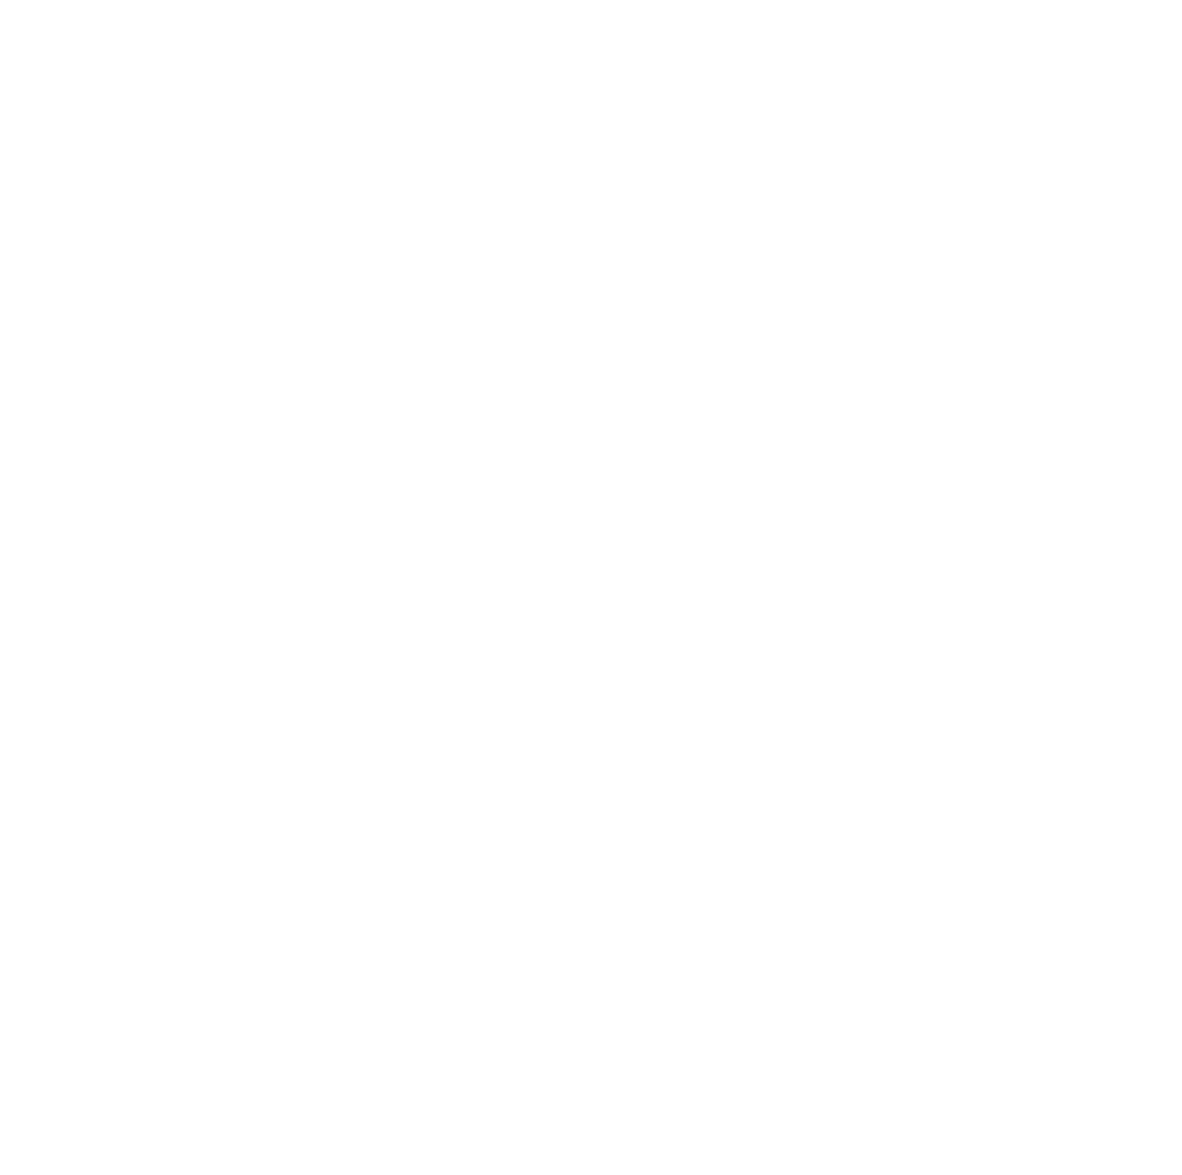

In [42]:
model.to(device)
criterion = nn.L1Loss().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
epochs = 10

for epoch in range(epochs):
    for batch, y_batch in tqdm(dataloader):
        t = torch.randint(0, T, (BATCH_SIZE,), device=device).long()
        # Genera ruido en avance
        x_noisy, noise = forward_diffusion_sample(batch, t, device)
        # Aplica la U-Net
        noise_pred = model(x_noisy, t)

        #Aprendizaje
        loss = criterion(noise, noise_pred)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    if epoch % 1 == 0 and step == 0:
        print(f"Epoch {epoch} | Loss: {loss.item()} ")
        sample_plot_image()   

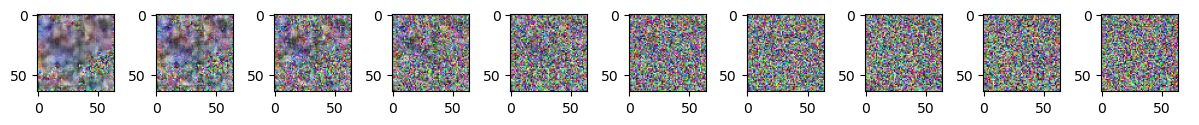

In [13]:
sample_plot_image()  

In [47]:
#torch.save(model.state_dict(), 'diffusion.model')